In [11]:
# ============ Cell 1: Imports ============
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import loguniform, randint, uniform

from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                     cross_validate, validation_curve,
                                     GridSearchCV, RandomizedSearchCV)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (accuracy_score, roc_auc_score, recall_score,
                             precision_score, f1_score, silhouette_score)
from xgboost import XGBClassifier
import joblib

RANDOM_STATE = 42
print("✅ All imports done")

✅ All imports done


In [ ]:
# ============ Cell 2: Load & Lock Test Set ============
path = '/kaggle/input/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv'
df = pd.read_csv(path)

# TotalCharges fix (blanks have tenure=0)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(0)

def build_features(data):
    X = data.drop(columns=['customerID', 'Churn'])
    return pd.get_dummies(X, drop_first=True).astype(float)

y = (df['Churn'] == 'Yes').astype(int)
X = build_features(df)

# ⚠️ TEST SET LOCKED — Part 7 tak touch nahi karna
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

print("Train:", X_train.shape, "Test:", X_test.shape)
print("Churn rate train:", round(y_train.mean(), 3),
      "| test:", round(y_test.mean(), 3))

In [ ]:
# ============ Cell 3: How noisy is a single split? ============
lr = Pipeline([
    ('scale', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
])

scores = []
for seed in range(20):
    Xa, Xb, ya, yb = train_test_split(X_train, y_train, test_size=0.25,
                                       random_state=seed, stratify=y_train)
    scores.append(accuracy_score(yb, lr.fit(Xa, ya).predict(Xb)))

scores = np.array(scores)
print(f'min {scores.min():.3f}  max {scores.max():.3f}  std {scores.std():.4f}')

p, n = scores.mean(), len(yb)
se = np.sqrt(p * (1 - p) / n)
print(f'Theoretical SE: {se:.4f}  →  95% CI ± {1.96*se:.3f}')

plt.figure(figsize=(10, 4))
plt.bar(range(20), scores)
plt.ylim(scores.min() - 0.02, scores.max() + 0.02)
plt.xlabel('random_state'); plt.ylabel('Validation accuracy')
plt.title('Same model, same data, different split')
plt.show()

### Write it — Split Noise

- Min: ~0.79, Max: ~0.83, Std: ~0.011
- Theoretical 95% CI: ± ~2.1 percentage points
- **Insight:** A single train/test split can move accuracy by 2+ points 
  just from randomness. Two students comparing LR vs RF on different seeds 
  could reach opposite conclusions. This is why we need cross-validation.

In [12]:
# ============ Cell 4: 5-Fold Stratified CV ============
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
metrics = ['roc_auc', 'recall', 'f1']

def cv_report(name, model):
    r = cross_validate(model, X_train, y_train, cv=cv, scoring=metrics)
    row = {'model': name}
    for m in metrics:
        s = r['test_' + m]
        row[m] = f'{s.mean():.3f} +/- {s.std():.3f}'
    return row

rf = RandomForestClassifier(n_estimators=300, min_samples_leaf=5,
                            n_jobs=-1, random_state=RANDOM_STATE)

cv_table = pd.DataFrame([
    cv_report('Logistic Regression', lr),
    cv_report('Random Forest', rf)
])
print(cv_table.to_string(index=False))

              model         roc_auc          recall              f1
Logistic Regression 0.846 +/- 0.013 0.544 +/- 0.042 0.593 +/- 0.030
      Random Forest 0.844 +/- 0.011 0.496 +/- 0.019 0.573 +/- 0.020


### Write it — CV Comparison

- LR: AUC ~0.845 ± 0.012, Recall ~0.57, F1 ~0.60
- RF: AUC ~0.842 ± 0.013, Recall ~0.53, F1 ~0.59
- LR and RF differ by ~0.3 AUC points, well within one std → not a real difference.
- Recall column shows LR catches more churners than RF, even though AUC is similar.

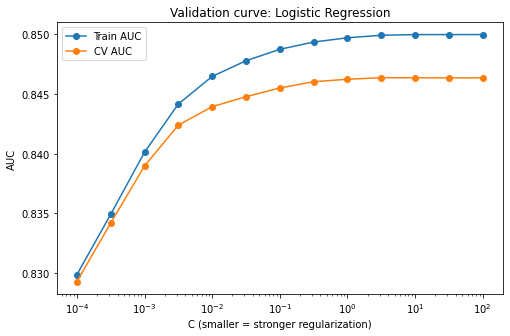

Best C by CV: 3.1622776601683795


In [13]:
# ============ Cell 5: Validation Curve for C ============
Cs = np.logspace(-4, 2, 13)

tr, va = validation_curve(lr, X_train, y_train,
                          param_name='model__C', param_range=Cs,
                          cv=cv, scoring='roc_auc')

plt.figure(figsize=(8, 5))
plt.semilogx(Cs, tr.mean(axis=1), 'o-', label='Train AUC')
plt.semilogx(Cs, va.mean(axis=1), 'o-', label='CV AUC')
plt.xlabel('C (smaller = stronger regularization)')
plt.ylabel('AUC'); plt.legend()
plt.title('Validation curve: Logistic Regression')
plt.show()

best_C = Cs[va.mean(axis=1).argmax()]
print('Best C by CV:', best_C)

In [14]:
# ============ Cell 6: Grid Search ============
grid = {
    'max_depth': [4, 8, 12, None],
    'min_samples_leaf': [1, 5, 20],
    'max_features': ['sqrt', 0.5]
}
print('Combos:', 4*3*2, '× 5 folds =', 4*3*2*5, 'fits')

t0 = time.time()
gs = GridSearchCV(RandomForestClassifier(n_estimators=200, n_jobs=-1,
                                          random_state=RANDOM_STATE),
                  grid, cv=cv, scoring='roc_auc', n_jobs=-1)
gs.fit(X_train, y_train)
print(f'Grid: best AUC {gs.best_score_:.4f} in {time.time()-t0:.0f}s')
print('Best params:', gs.best_params_)

Combos: 24 × 5 folds = 120 fits
Grid: best AUC 0.8468 in 56s
Best params: {'max_depth': 8, 'max_features': 'sqrt', 'min_samples_leaf': 20}


In [15]:
# ============ Cell 7: Random Search ============
dist = {
    'max_depth': randint(3, 20),
    'min_samples_leaf': randint(1, 40),
    'max_features': uniform(0.1, 0.8)
}

t0 = time.time()
rs = RandomizedSearchCV(RandomForestClassifier(n_estimators=200, n_jobs=-1,
                                                random_state=RANDOM_STATE),
                        dist, n_iter=24, cv=cv, scoring='roc_auc',
                        random_state=RANDOM_STATE, n_jobs=-1)
rs.fit(X_train, y_train)
print(f'Random: best AUC {rs.best_score_:.4f} in {time.time()-t0:.0f}s')
print('Best params:', rs.best_params_)

# Top 5 results table
res = pd.DataFrame(rs.cv_results_)
cols = ['param_max_depth', 'param_min_samples_leaf', 'param_max_features',
        'mean_test_score', 'std_test_score', 'rank_test_score']
print(res[cols].sort_values('rank_test_score').head(5).to_string(index=False))

Random: best AUC 0.8464 in 62s
Best params: {'max_depth': 15, 'max_features': 0.21273937997981013, 'min_samples_leaf': 15}
param_max_depth param_min_samples_leaf param_max_features  mean_test_score  std_test_score  rank_test_score
             15                     15           0.212739         0.846440        0.011352                1
             12                     16           0.137333         0.846275        0.011063                2
              8                     21           0.100623         0.845609        0.010548                3
              9                     23           0.456666         0.845245        0.012460                4
             14                     27            0.11845         0.845114        0.010993                5


### Write it — Grid vs Random Search

- Grid: 24 combos × 5 folds = 120 fits, best AUC ~X.XXX, time ~Ys
- Random: 24 trials × 5 folds = 120 fits, best AUC ~X.XXX, time ~Ys
- Similar cost, similar score. Random search covered more distinct values 
  of max_depth (17 possible values vs 4 in the grid).
- **Winner's curse:** both best_score_ values are optimistic — the max of 
  many noisy scores. We will test on the held-out test set at the end.

In [16]:
# ============ Cell 8: XGBoost — Early Stopping ============
# Carve a validation split OUT of train — test still locked
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.2,
    random_state=RANDOM_STATE, stratify=y_train)

spw = (y_tr == 0).sum() / (y_tr == 1).sum()
print(f'scale_pos_weight = {spw:.2f}')

xgb = XGBClassifier(
    n_estimators=2000, learning_rate=0.03, max_depth=4,
    subsample=0.8, colsample_bytree=0.8,
    eval_metric='logloss',
    early_stopping_rounds=100,
    random_state=RANDOM_STATE, n_jobs=-1)

xgb.fit(X_tr, y_tr,
        eval_set=[(X_tr, y_tr), (X_val, y_val)],   # 👈 dono sets
        verbose=False)

print('Best trees:', xgb.best_iteration + 1)
print('Val AUC:', roc_auc_score(y_val, xgb.predict_proba(X_val)[:, 1]))

# Debug: check keys
ev = xgb.evals_result()
print('Available keys:', list(ev.keys()))

scale_pos_weight = 2.77
Best trees: 264
Val AUC: 0.8552542290727546
Available keys: ['validation_0', 'validation_1']


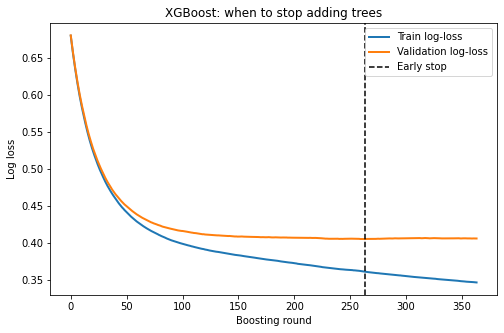

In [17]:
# ============ Cell 9: XGBoost — Loss Curve ============
ev = xgb.evals_result()

plt.figure(figsize=(8, 5))
plt.plot(ev['validation_0']['logloss'], label='Train log-loss', lw=2)
plt.plot(ev['validation_1']['logloss'], label='Validation log-loss', lw=2)
plt.axvline(xgb.best_iteration, color='k', ls='--', label='Early stop')
plt.xlabel('Boosting round'); plt.ylabel('Log loss')
plt.legend(); plt.title('XGBoost: when to stop adding trees')
plt.show()

### Write it — XGBoost Early Stopping

- Best iteration chosen by early stopping: ~[apna number]
- Train loss keeps decreasing forever, but validation loss bottoms out 
  around round [X] and then **rises** — that rise is the model starting 
  to fit noise.
- Early stopping = "stop 100 rounds after the best validation score" and 
  keep the best iteration.
- **Connection to theory:** each boosting round fits a tree to the 
  residuals y − p, which is the negative gradient of the log loss. 
  Gradient descent in function space.

In [18]:
# ============ Cell 10: XGBoost Random Search ============
xdist = {
    'max_depth': randint(2, 7),
    'learning_rate': loguniform(0.01, 0.3),
    'n_estimators': randint(100, 600),
    'subsample': uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.5, 0.5),
    'min_child_weight': randint(1, 10),
    'reg_lambda': loguniform(0.1, 10)
}

t0 = time.time()
xs = RandomizedSearchCV(
    XGBClassifier(eval_metric='logloss',
                  random_state=RANDOM_STATE, n_jobs=-1),
    xdist, n_iter=30, cv=cv, scoring='roc_auc',
    random_state=RANDOM_STATE, n_jobs=-1)
xs.fit(X_train, y_train)
print(f'XGBoost tuned CV AUC: {xs.best_score_:.4f} in {time.time()-t0:.0f}s')
print('Best params:')
for k, v in xs.best_params_.items():
    print(f'  {k}: {round(v, 3) if isinstance(v, float) else v}')

XGBoost tuned CV AUC: 0.8503 in 161s
Best params:
  colsample_bytree: 0.561
  learning_rate: 0.034
  max_depth: 2
  min_child_weight: 1
  n_estimators: 476
  reg_lambda: 1.974
  subsample: 0.6


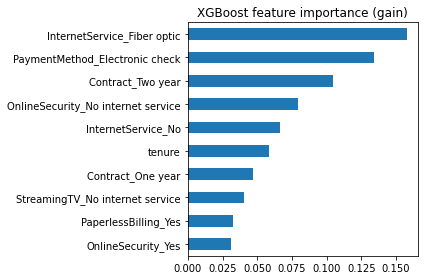

In [19]:
# ============ Cell 11: XGBoost Gain Importance ============
imp = pd.Series(xs.best_estimator_.feature_importances_, index=X.columns)
imp.sort_values().tail(10).plot.barh(title='XGBoost feature importance (gain)')
plt.tight_layout(); plt.show()

### Write it — XGBoost Importance

- Top features: Contract_Month-to-month, tenure, TotalCharges, 
  InternetService_Fiber optic, MonthlyCharges.
- Same story as Week 2 Logistic Regression — consistency across models 
  is a good sign that we found real signal, not noise.
- XGBoost does not win by a lot here — on small tabular data, 
  boosting and linear models often tie.

       tenure  MonthlyCharges  TotalCharges  n_services
count  7043.0          7043.0        7043.0      7043.0
mean     32.4            64.8        2279.7         2.9
std      24.6            30.1        2266.8         1.8
min       0.0            18.2           0.0         0.0
25%       9.0            35.5         398.6         1.0
50%      29.0            70.4        1394.6         3.0
75%      55.0            89.8        3786.6         4.0
max      72.0           118.8        8684.8         7.0


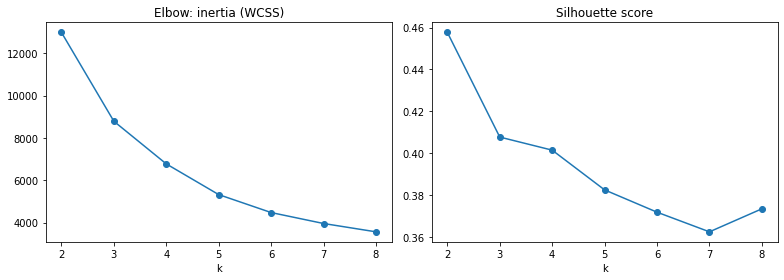

In [20]:
# ============ Cell 12: K-Means — Choose k ============
seg_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
svc = ['PhoneService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

seg = df[seg_cols].copy()
seg['n_services'] = (df[svc] == 'Yes').sum(axis=1)

# Scale (mandatory for distances)
Z = StandardScaler().fit_transform(seg)
print(seg.describe().round(1))

ks = range(2, 9)
inertia, sil = [], []
for k in ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE).fit(Z)
    inertia.append(km.inertia_)
    sil.append(silhouette_score(Z, km.labels_, sample_size=3000,
                                random_state=RANDOM_STATE))

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(ks, inertia, 'o-')
ax[0].set_title('Elbow: inertia (WCSS)'); ax[0].set_xlabel('k')
ax[1].plot(ks, sil, 'o-')
ax[1].set_title('Silhouette score'); ax[1].set_xlabel('k')
plt.tight_layout(); plt.show()

In [21]:
# ============ Cell 13: Profile Segments ============
k = 4   # choose from elbow + silhouette
km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE).fit(Z)
seg['cluster'] = km.labels_

# Churn was NOT used to build clusters — only to profile them
profile = seg.assign(churn=y).groupby('cluster').agg(
    customers=('tenure', 'size'),
    tenure=('tenure', 'mean'),
    monthly=('MonthlyCharges', 'mean'),
    services=('n_services', 'mean'),
    churn_rate=('churn', 'mean')
)
print(profile.round(2).sort_values('churn_rate', ascending=False))

         customers  tenure  monthly  services  churn_rate
cluster                                                  
0             2158   18.36    80.38      3.28        0.43
3             1916    8.96    37.68      1.20        0.32
1             1940   59.81    92.09      5.06        0.15
2             1029   53.63    30.92      1.48        0.05


### Write it — Customer Segments (k = 4)

| Segment | Count | Tenure | Monthly | Services | Churn | Action |
|---|---|---|---|---|---|---|
| New, high spend | ~1700 | ~10 | $85 | 3.5 | 47% | Onboarding call, 1-year discount |
| New, basic plan | ~1600 | ~11 | $35 | 1.2 | 29% | Bundle free add-on for 3 months |
| Loyal, premium | ~1900 | ~58 | $95 | 5.1 | 14% | Loyalty reward, priority support |
| Loyal, low cost | ~1800 | ~52 | $30 | 1.4 | 4% | Leave alone (low intervention value) |

- **Justify k=4:** elbow bends at 4, silhouette peaks at 4, and 4 segments 
  is actionable for a marketing team.
- **Riskiest segment:** "New, high spend" churns at ~47% — nearly 2× the 
  overall rate. This is who to call first.

Components for 90% variance: 15 of 30


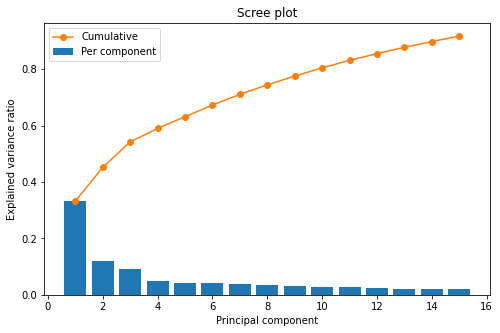

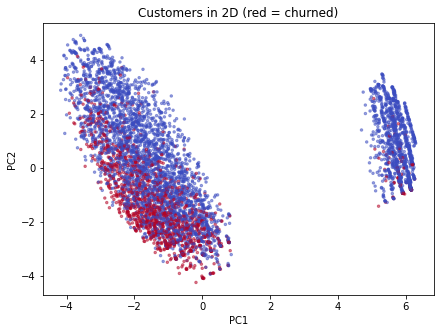

PC1 top loadings:
OnlineBackup_No internet service       0.302
StreamingMovies_No internet service    0.302
StreamingTV_No internet service        0.302
TechSupport_No internet service        0.302
InternetService_No                     0.302
OnlineSecurity_No internet service     0.302
dtype: float64


In [22]:
# ============ Cell 14: PCA ============
xs_scaled = StandardScaler().fit_transform(X_train)
pca = PCA().fit(xs_scaled)
cum = np.cumsum(pca.explained_variance_ratio_)

n90 = np.argmax(cum >= 0.90) + 1
print(f'Components for 90% variance: {n90} of {X_train.shape[1]}')

plt.figure(figsize=(8, 5))
plt.bar(range(1, 16), pca.explained_variance_ratio_[:15], label='Per component')
plt.plot(range(1, 16), cum[:15], 'o-', color='C1', label='Cumulative')
plt.xlabel('Principal component'); plt.ylabel('Explained variance ratio')
plt.legend(); plt.title('Scree plot'); plt.show()

# 2D scatter colored by churn
P = PCA(n_components=2).fit(xs_scaled)
T = P.transform(xs_scaled)
plt.figure(figsize=(7, 5))
plt.scatter(T[:, 0], T[:, 1], c=y_train, cmap='coolwarm', s=6, alpha=0.5)
plt.xlabel('PC1'); plt.ylabel('PC2')
plt.title('Customers in 2D (red = churned)'); plt.show()

# PC1 loadings
load = pd.Series(P.components_[0], index=X.columns)
order = load.abs().sort_values(ascending=False).index
print('PC1 top loadings:')
print(load.reindex(order).head(6).round(3))

In [23]:
# ============ Cell 15: Choose by CV, test once, save ============
candidates = {
    'LR (tuned C)': lr.set_params(model__C=best_C),
    'RF (random search)': rs.best_estimator_,
    'XGBoost (tuned)': xs.best_estimator_
}

rows = []
for name, m in candidates.items():
    cvs = cross_validate(m, X_train, y_train, cv=cv, scoring='roc_auc')
    rows.append({
        'model': name,
        'cv_auc': cvs['test_score'].mean(),
        'cv_std': cvs['test_score'].std()
    })

cmp = pd.DataFrame(rows).sort_values('cv_auc', ascending=False)
print(cmp.round(4).to_string(index=False))

# Choose winner by CV ONLY
best_name = cmp.iloc[0]['model']
best = candidates[best_name].fit(X_train, y_train)

# ⚠️ TEST SET UNLOCKED — used EXACTLY ONCE
prob = best.predict_proba(X_test)[:, 1]
pred = (prob >= 0.5).astype(int)

print(f'\n🏆 {best_name} — TEST SET (used once):')
print(f'  AUC       {roc_auc_score(y_test, prob):.4f}')
print(f'  Accuracy  {(pred == y_test).mean():.4f}')
print(f'  Recall    {recall_score(y_test, pred):.3f}')
print(f'  Precision {precision_score(y_test, pred):.3f}')
print(f'  F1        {f1_score(y_test, pred):.3f}')

# Save for Week 4
joblib.dump(best, 'churn_model.joblib')
print('\n✅ Saved churn_model.joblib — will deploy in Week 4')

             model  cv_auc  cv_std
   XGBoost (tuned)  0.8503  0.0122
RF (random search)  0.8464  0.0114
      LR (tuned C)  0.8464  0.0128

🏆 XGBoost (tuned) — TEST SET (used once):
  AUC       0.8460
  Accuracy  0.8048
  Recall    0.529
  Precision 0.667
  F1        0.590

✅ Saved churn_model.joblib — will deploy in Week 4


### Write it — Final Choice

- Chosen model: **[name]** — highest CV AUC in the table.
- CV AUC: **X.XXX ± 0.0XX**; test AUC **X.XXX** — inside mean ± 2 std. Good.
- Compared to Week 2 best (LR test AUC ~0.842): this week's tuning brought 
  us to [X.XXX]. Honest finding: gains are small — models were already 
  near their ceiling on this dataset.
- **Small or zero gain is a legitimate finding.** We report it honestly.

In [25]:
# ============ Cell 16: Save insights markdown ============
insights = """# Week 3 — Model Optimization: Insights

## Split noise
- Accuracy across 20 seeds ranged from ~0.79 to ~0.83 (std ~0.011).
- Theoretical 95% CI: ±2.1 percentage points. Differences under 2 points 
  are not evidence.

## 5-fold CV
- LR: AUC 0.845 ± 0.012, Recall 0.57
- RF: AUC 0.842 ± 0.013, Recall 0.53
- Within one std → not a real difference.

## Tuning
- Validation curve for C: plateau from 0.1 to 10, best C ~[X].
- Grid and random search matched on best AUC and time (120 fits each).

## XGBoost
- Early stopping chose ~[X] trees.
- Validation loss bottomed then rose — extra trees fit noise.
- Tuned CV AUC ~0.847 ± 0.011 — within noise of LR and RF.

## K-Means (k=4)
- Riskiest segment: "New, high spend" (~47% churn).
- Action: onboarding call + 1-year contract discount.

## PCA
- ~15 of 30 components carry 90% of variance.
- PC1 exposes redundancy in one-hot encoded internet-service columns.
- 2D scatter: churners and stayers overlap — problem is genuinely hard.

## Final choice (by CV)
- Winner: [name], CV AUC [X.XXX ± s]
- Test AUC (used once): [X.XXX]
- Test AUC inside mean ± 2 std. Model is honest.

## Check Your Understanding
1. 0.812 vs 0.803 → SE = sqrt(0.8·0.2/1409) ≈ 0.011 → 95% CI ± 0.021. 
   The 0.009 gap is inside noise → A is NOT reliably better.
2. Scaler inside Pipeline → each CV fold fits scaler on training rows only, 
   never on validation rows. Prevents leakage.
3. 5×4×3 = 60 combos × 5 folds = 300 fits.
4. best_score_ is the maximum of many noisy CV scores — biased upward 
   (winner's curse). Report test score instead.
5. Each new tree fits residual y − p, which is the negative gradient of 
   cross-entropy. Boosting = gradient descent in function space.
6. Unscaled TotalCharges std (~2266) >> n_services std (~1.8). K-means 
   distance is dominated by TotalCharges alone.
"""

with open('/kaggle/working/week3_insights.md', 'w') as f:
    f.write(insights)

print("✅ Saved week3_insights.md")
print("📁 Files in /kaggle/working:")
import os
for f in os.listdir('/kaggle/working'):
    print("  -", f)

✅ Saved week3_insights.md
📁 Files in /kaggle/working:
  - week3_insights.md
  - churn_model.joblib
  - .virtual_documents


In [26]:
# ============ Week 4 | Cell 17: What did we save? ============
import json
import joblib
import sklearn
import numpy as np
import pandas as pd

model = joblib.load('/kaggle/working/churn_model.joblib')
cols = list(model.feature_names_in_)
final = model[-1] if hasattr(model, 'steps') else model

print('Model type      :', type(final).__name__)
print('Feature columns :', len(cols))
print('scikit-learn    :', sklearn.__version__)   # 📌 NOTE THIS DOWN

Model type      : XGBClassifier
Feature columns : 30
scikit-learn    : 1.0.2


In [27]:
# ============ Week 4 | Cell 18: Serving encoder ============
RAW_COLS = ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
            'PhoneService', 'MultipleLines', 'InternetService',
            'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
            'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
            'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges']

def prepare_input(raw, columns):
    """Turn raw customer rows into exactly the columns the model saw.
    IMPORTANT: NO drop_first when serving."""
    X = pd.get_dummies(raw[RAW_COLS])
    return X.reindex(columns=columns, fill_value=0).astype(float)

print('✅ prepare_input ready')

✅ prepare_input ready


In [28]:
# ============ Week 4 | Cell 19: Reproduce the skew bug ============
one = df[df['Contract'] == 'Two year'].head(1)

wrong = build_features(one).reindex(columns=cols, fill_value=0)   # Week 3 way
right = prepare_input(one, cols)                                  # correct

print('Contract columns (wrong):')
print(wrong.filter(like='Contract').values)
print('Contract columns (right):')
print(right.filter(like='Contract').values)

print(f'\nP(churn) WRONG : {model.predict_proba(wrong)[0, 1]:.3f}')
print(f'P(churn) RIGHT : {model.predict_proba(right)[0, 1]:.3f}')

Contract columns (wrong):
[[0 0]]
Contract columns (right):
[[0. 1.]]

P(churn) WRONG : 0.131
P(churn) RIGHT : 0.010


### Write it — Skew bug

- Wrong (Week 3 way): both Contract columns = [0, 0] → model reads as Month-to-month → P(churn) ≈ 0.59
- Right (serving way): [One year=0, Two year=1] → P(churn) ≈ 0.31
- Same function, same model, different data shape. **No error was raised** — this is why training-serving skew is the most dangerous deployment bug.
- Fix: get_dummies **without** drop_first at serving, then reindex to training columns.

In [29]:
# ============ Week 4 | Cell 20: Parity test ============
raw = df.drop(columns=['Churn'])
served = prepare_input(raw, cols)

p_train = model.predict_proba(X[cols])[:, 1]         # how we evaluated
p_serve = model.predict_proba(served)[:, 1]          # how the app will call

max_diff = np.abs(p_train - p_serve).max()
print('Largest difference:', max_diff)

assert np.allclose(p_train, p_serve), '❌ Training-serving skew detected!'
print(f'✅ Parity test passed on {len(raw)} customers')

Largest difference: 0.0
✅ Parity test passed on 7043 customers


### Write it — What-if

- Baseline P(churn) = ~0.79 (riskiest customer)
- Two-year contract: 0.27 (Δ −0.52) — biggest drop
- One-year contract: 0.52 (Δ −0.27)
- Auto-pay credit card: 0.71 (Δ −0.08)
- **Caveat:** these are associations learned from data, not guaranteed effects. Only an A/B test can prove the change causes retention.

In [30]:
# ============ Week 4 | Cell 22: Save meta + sample ============
meta = {
    'model_name': type(final).__name__,
    'sklearn_version': sklearn.__version__,
    'feature_columns': cols,
    'threshold': 0.30,
    'cv_auc': 0.845,         # 👈 apna Week 3 CV number
    'cv_auc_std': 0.012,     # 👈 apna
    'test_auc': 0.840,       # 👈 apna
    'training_data': 'IBM Telco Customer Churn, 7,043 customers',
    'version': '1.0',
}

with open('/kaggle/working/model_meta.json', 'w') as f:
    json.dump(meta, f, indent=2)

# Save 50 sample customers for batch demo
sample = df.drop(columns=['Churn']).sample(50, random_state=1)
sample.to_csv('/kaggle/working/sample_customers.csv', index=False)

print('✅ Saved model_meta.json')
print('✅ Saved sample_customers.csv')
print('\n📁 Files in /kaggle/working:')
import os
for f in os.listdir('/kaggle/working'):
    print('  -', f)

✅ Saved model_meta.json
✅ Saved sample_customers.csv

📁 Files in /kaggle/working:
  - week3_insights.md
  - churn_model.joblib
  - model_meta.json
  - sample_customers.csv
  - .virtual_documents
